<a href="https://colab.research.google.com/github/divyavashist9758-eng/Advertising-Sales/blob/main/regressionpracticeipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error ,mean_squared_error , r2_score


In [3]:
df=pd.read_csv("/content/Advertising.csv")

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [15]:
df=df.drop(columns=["Unnamed: 0"], errors='ignore')

In [16]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [17]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


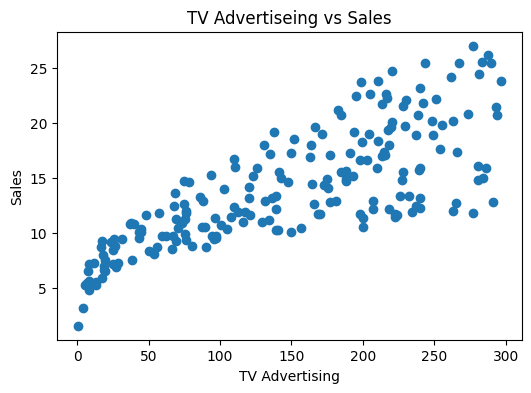

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df["TV"],df["Sales"])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertiseing vs Sales")
plt.show()

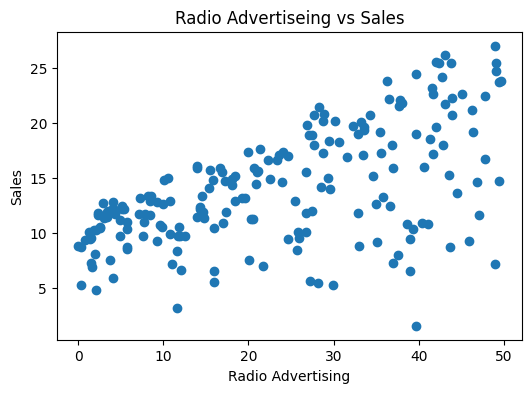

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df["Radio"],df["Sales"])
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio Advertiseing vs Sales")
plt.show()

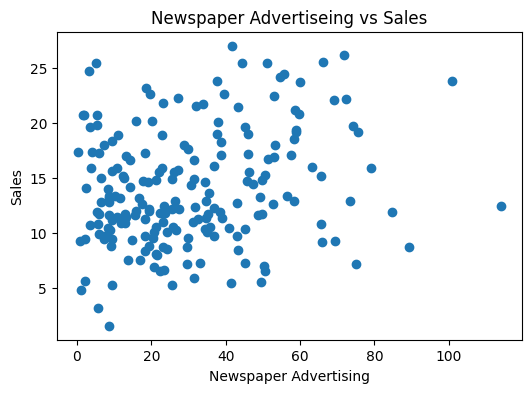

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"],df["Sales"])
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.title("Newspaper Advertiseing vs Sales")
plt.show()

In [22]:
X=df[["TV","Radio","Newspaper"]]
Y=df["Sales"]

In [23]:
X_train,X_test,Y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [24]:
X_train

,TV,Radio,Newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [25]:
X_test

,TV,Radio,Newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2
115,75.1,35.0,52.7
69,216.8,43.9,27.2
170,50.0,11.6,18.4
174,222.4,3.4,13.1
45,175.1,22.5,31.5


In [26]:
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [27]:
y_pred=model.predict(X_test)

In [28]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE",mae)
print("MSE",mse)
print("RMSE",rmse)
print("R2",r2)

MAE 1.4607567168117603
MSE 3.1740973539761033
RMSE 1.78159966153345
R2 0.899438024100912


In [31]:
result=pd.DataFrame ({
 "Actual Sales" :y_test.values,
 "Predicted Sales" :y_pred
})
result.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


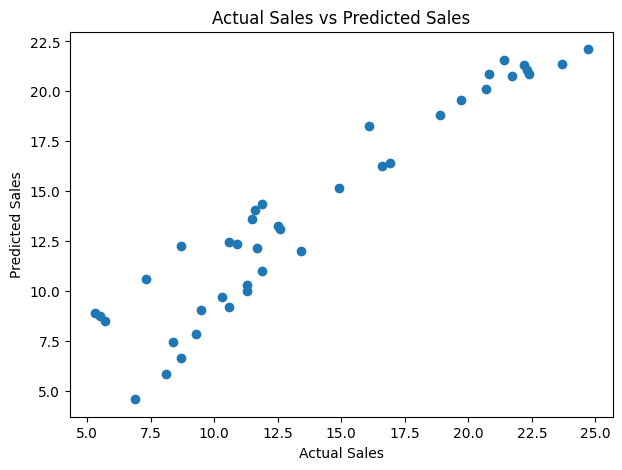

In [32]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.show()

In [33]:
print("Intercept:",model.intercept_)
for feature,coefficient in zip(X.columns,model.coef_):
  print(feature, ":" , coefficient)

Intercept: 2.979067338122629
TV : 0.044729517468716326
Radio : 0.18919505423437652
Newspaper : 0.0027611143413671935


In [34]:
new_data=pd.DataFrame({
    "TV":[100],
    "Radio":[50],
    "Newspaper":[25]
})
prediction=model.predict(new_data)
print("predicted Sales :", prediction[0])

predicted Sales : 16.980799655247267
